<a href="https://colab.research.google.com/github/yusuf-codes10/touir-youcef-abderahim-ml-automal-homework/blob/main/machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning TP Project | Touir Youcef Abderahim

## 1- installing and setting up the datasets from Kaggle

In [2]:
# STEP 1 — Set Kaggle credentials
import os
from getpass import getpass

os.environ['KAGGLE_USERNAME'] = input("Enter Kaggle username: ")
os.environ['KAGGLE_API_TOKEN'] = getpass("Enter Kaggle API key: ")

Enter Kaggle username: youcefcopy
Enter Kaggle API key: ··········


In [3]:
# STEP 2 — Install Kaggle & download datasets
!pip install kaggle

In [4]:
# STEP 3 — Download datasets
!kaggle datasets download -d vjchoudhary7/customer-segmentation-tutorial-in-python
!kaggle datasets download -d mlg-ulb/creditcardfraud

Dataset URL: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python
License(s): other
customer-segmentation-tutorial-in-python.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
creditcardfraud.zip: Skipping, found more recently modified local copy (use --force to force download)


In [5]:
# STEP 4 — Unzip datasets
!unzip -q customer-segmentation-tutorial-in-python.zip
!unzip -q creditcardfraud.zip

## EDA (Laoding the Data)

In [6]:
import pandas as pd

mall_df = pd.read_csv('Mall_Customers.csv')
fraud_df = pd.read_csv('creditcard.csv')

### Project 1 – Mall *Customers*

#### Plan
Project 1 – Mall Customers:

Shape, dtypes, null check
Distribution of Age, Income, Spending Score (histograms)
Gender breakdown (count plot)
Correlation between features

Project 2 – Credit Card Fraud:

Shape, dtypes, null check
Class imbalance (how many frauds vs normal — very imbalanced!)
Distribution of Amount and Time
Correlation heatmap


Then after EDA:

Project 1 → Clustering (K-Means + one other)
Project 2 → Preprocessing → Classification model → Evaluation
AutoML review (Markdown)
AutoML on Project 2

In [8]:
# 1. Load
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

mall_df = pd.read_csv('Mall_Customers.csv')
mall_df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [9]:
# 2. Shape, dtypes, null check
print("Shape:", mall_df.shape)
print("\nDtypes:\n", mall_df.dtypes)
print("\nNull values:\n", mall_df.isnull().sum())
print("\nPreview:\n", mall_df.head())

Shape: (200, 5)

Dtypes:
 CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Null values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Preview:
    CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


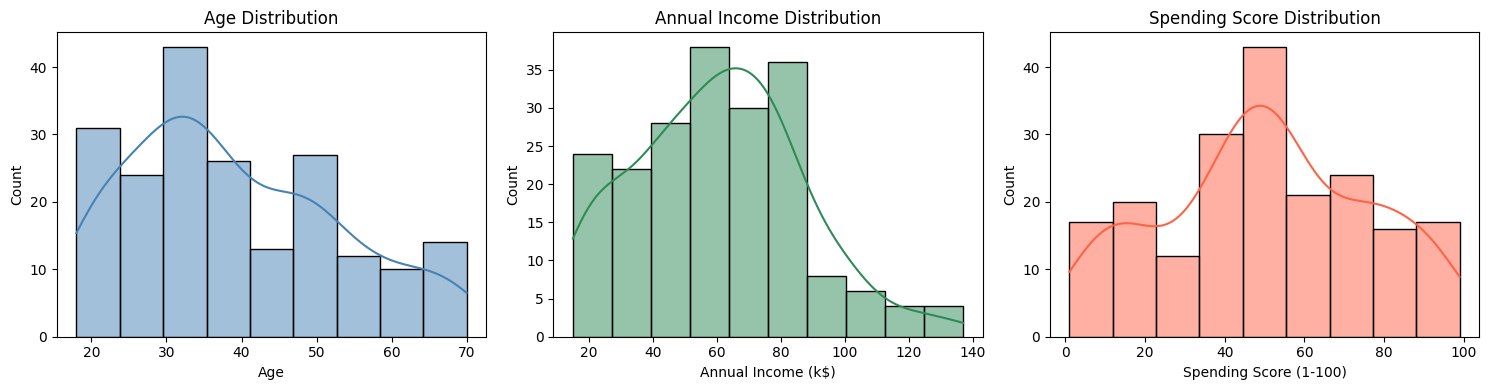

In [10]:
# 3. Distributions — Age, Income, Spending Score
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(mall_df['Age'], ax=axes[0], kde=True, color='steelblue')
axes[0].set_title('Age Distribution')

sns.histplot(mall_df['Annual Income (k$)'], ax=axes[1], kde=True, color='seagreen')
axes[1].set_title('Annual Income Distribution')

sns.histplot(mall_df['Spending Score (1-100)'], ax=axes[2], kde=True, color='tomato')
axes[2].set_title('Spending Score Distribution')

plt.tight_layout()
plt.show()